# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [8]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])
print(A @ e_1)
print(A @ e_2)
print(A @ e_3)

[1 4 7]
[2 5 8]
[3 6 9]


By the definition of matrix multiplication, we multiply the rows in the left matrix by the columns in the right matrix. We can envision it as stacking the two matrices on top of eachother, wherever they overlap that is the shape of our final result, and while doing the multiplication row by row, wherever the row overlaps with the column is the spot the sum of the product goes to. In the e_1 case, we multiply the first row [1,2,3] by [1,0,0] giving us 1+0+0 then [4,5,6] by [1,0,0] giving us 4+0+0, then lastly 7,8,9 by 1,0,0 giving us 7+0+0, giving the final form [1 4 7] vector. So essentially we just take the first column in the original matrix as our final result since the 1,0,0 column vector we are multiplying with essentially erases the other two columns with the 0,0 after the 1. In the e_2 case, applying a similar line of thought, we select the second column in the original matrix. And then lastly in the e_3 case, we select the last column in the original matrix.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [9]:
u = np.ones(3)
print(A @ u)

[ 6. 15. 24.]


We are still doing matrix multiplication with the same shapes, so our result should be another 3 element vector. However, since we have 1,1,1 now instead of some 0s, nothing gets "erased" and instead we take the sum of all the rows as we progress row by row, the sum of the first row is 6, the second 15, and third 24, thus giving us the final result.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [10]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])
print(A @ x)


[-2  4 11]


When you multiply A by x you just get x as the result. When you multiply an identity matrix with any vector, it simply gives you the vector as the result, hence the name identity matrix. This makes sense because by the definition of matrix multiplication, as we multiply each row of A with x, we are essentially selecting the first element of x for the first element of the result, second element of x for the second element of the result, etc. as the 0s in the other places cancel out the other elements. This just gives us the original x.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [11]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])
print(A @ x)
B = np.array([ [0,1,0],
              [0,0,1],
              [1,0,0]])
print(B @ x)

[11 -2  4]
[ 4 11 -2]


Again, the shapes for both matrices are the same as before, so the shape of the result makes sense. As for the elements, now instead of selecting the 1st element in x for the 1st element in the result, we select the last element of x for the first element in the result, denoted by the first row vector being 0,0,1 as opposed to 1,0,0 from before. So essentially wherever the 1 is whatelement from x gets selected, so the result is x shuffled around to wherever the 1s are in the rows of the matrix A. 1 is in position 3,1,2 so the result is x's 3rd element, then 1st, then 4, giving us 11, -2, 4. Then for B, the positions of the 1s are 2,3,1, so it gives us 4,11,-2.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [12]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [13]:
print(A @ e_1)
print(A @ e_2)
print(A @ e_3)

[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


When taking a Markov transition matrix and multiplying it with e_1, e_2, and e_3, we essentially just get the column vectors in the original matrix, meaning the output is the distribution of the proportion of observations who move from state 1 to state 1, 2, and 3 for e_1. This is the same for e_2 and e_3 as well, wherever the 1 is in the e vectors, that is the state we are getting the distribution of its transition space.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [14]:
print(A @ A @ A @ A @ A @ e_1)
print(A @ A @ A @ A @ A @ e_2)
print(A @ A @ A @ A @ A @ e_3)

[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


For all the e vectors you get virtually the same distribution of the probability of transition output, this makes it seem that it is the case that if you multiply the original matrix a certain amount of times before doing your column vector multiplication, it essentially converges the probabilities to the same states.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [15]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])
state1 = np.array([1,0])
state1 @ T

array([0.25, 0.5 ])

The results in terms of the formula is that we get p_11 and p_12, this correlates to there is a .25 probability to transition from state 1 to state 1 and a .5 probability to transition from state 2 to state 1.

In [16]:
state1 @ T @ T

array([0.4375, 0.375 ])

Multiplying by T again, what we get next can be interpreted the same way, but now we have to change the context, as this is the second transition. We have that there is a .4375 probability to transition from state 1 to state 1 to state 1 with 2 transitions, and a .375 probability to transition from state 2 to state 1 to state 1 with 2 transitions. This is essentially a forecast of the state in two transitions. 

Note: I am stuck on this part, something is wrong here because the question makes me think we are interpreting it with starting in state 1, but by the problem definition of p_ij meaning j transitioning to i probability, this means doing state1 @ T gives us probability of going to state 1 from state 1 or 2, not starting at state 1 and going to state 1 or 2.

In [17]:
for i in range(10):
    state1 = state1 @ T
    print(state1)
    print(i+1)

[0.25 0.5 ]
1
[0.4375 0.375 ]
2
[0.390625 0.40625 ]
3
[0.40234375 0.3984375 ]
4
[0.39941406 0.40039062]
5
[0.40014648 0.39990234]
6
[0.39996338 0.40002441]
7
[0.40000916 0.3999939 ]
8
[0.39999771 0.40000153]
9
[0.40000057 0.39999962]
10


After the third transition, we see the two elements in the output vector start to settle down in terms of the change in their probabilities from the previous transition. After the third transition in the output we see that neither value changes much beyond the approximately .4 probabilities, and after the 4th the change is virtually 0.

In [18]:
state1 = np.array([0,1])
for i in range(10):
    state1 = state1 @ T
    print(state1)
    print(i+1)

[0.75 0.5 ]
1
[0.5625 0.625 ]
2
[0.609375 0.59375 ]
3
[0.59765625 0.6015625 ]
4
[0.60058594 0.59960938]
5
[0.59985352 0.60009766]
6
[0.60003662 0.59997559]
7
[0.59999084 0.6000061 ]
8
[0.60000229 0.59999847]
9
[0.59999943 0.60000038]
10


Now starting with a different initial state, we see that a similar pattern emerges, after the 3rd transition there is not much change in the probabilities, they essentially have converged to their .6 probabilities, and again after the 4th transition, any change is virtually 0.

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [19]:
import pandas as pd

data = pd.read_csv('data/cville_weather.csv')
print(data.isnull().sum())
data.head()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64


,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


There is some missing data issues, there are a lot of NaN values in DAPR, MDPR, SNOW, and SNWD columns.

In [20]:
data['rain'] = np.where(data['PRCP'] > 0, 1, 0) # indicate rain or no rain

In [21]:
import pandas as pd
import numpy as np

seq = np.array(data['rain'])
states = list(np.unique(seq)) # Get unique elements and convert to list
S = len(states)
T = len(seq)
tr_counts = np.zeros((S, S))

for t in range(1, T):
    x_tm1 = states.index(seq[t-1])
    x_t = states.index(seq[t])
    tr_counts[x_t, x_tm1] += 1

print('\nTransition Counts:\n', tr_counts)

sums = tr_counts.sum(axis=1, keepdims=True)
print('\nState Counts:\n', sums)

state_proportions = sums / np.sum(sums)
print('\nState proportions:\n', state_proportions)

tr_pr = np.divide(tr_counts, sums, out=np.zeros_like(tr_counts), where=sums!=0)
tr_pr_1 = tr_pr
print('\nTransition Proportions:\n')
transition_matrix = pd.DataFrame(np.round(tr_pr, 2), index=states, columns=states)
transition_matrix


Transition Counts:
 [[169.  63.]
 [ 62. 116.]]

State Counts:
 [[232.]
 [178.]]

State proportions:
 [[0.56585366]
 [0.43414634]]

Transition Proportions:



,0,1
0,0.73,0.27
1,0.35,0.65


If it was raining yesterday, there is a .65 probability to rain today, and if it was clear yesterday, there is a .27 probability to rain today.

In [22]:
initial_state = np.array([1,
                          0])
for i in range(10):
    initial_state = initial_state @ transition_matrix
    print(initial_state)
    print(i+1)

0    0.73
1    0.27
dtype: float64
1
0    0.6274
1    0.3726
dtype: float64
2
0    0.588412
1    0.411588
dtype: float64
3
0    0.573597
1    0.426403
dtype: float64
4
0    0.567967
1    0.432033
dtype: float64
5
0    0.565827
1    0.434173
dtype: float64
6
0    0.565014
1    0.434986
dtype: float64
7
0    0.564705
1    0.435295
dtype: float64
8
0    0.564588
1    0.435412
dtype: float64
9
0    0.564543
1    0.435457
dtype: float64
10


When starting from a clear day, the distribution converges to a fixed result after about 6 transition periods.

In [23]:
initial_state2 = np.array([0,
                          1])
for i in range(10):
    initial_state2 = initial_state2 @ transition_matrix
    print(initial_state2)
    print(i+1)

0    0.35
1    0.65
dtype: float64
1
0    0.483
1    0.517
dtype: float64
2
0    0.53354
1    0.46646
dtype: float64
3
0    0.552745
1    0.447255
dtype: float64
4
0    0.560043
1    0.439957
dtype: float64
5
0    0.562816
1    0.437184
dtype: float64
6
0    0.56387
1    0.43613
dtype: float64
7
0    0.564271
1    0.435729
dtype: float64
8
0    0.564423
1    0.435577
dtype: float64
9
0    0.564481
1    0.435519
dtype: float64
10


When starting from a rainy day, the distribution converges to a fixed result after about 8 transition periods.

C:\Users\wanns\AppData\Local\Temp\ipykernel_12480\716332018.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=data, x='PRCP', hue='rain', common_norm=False)


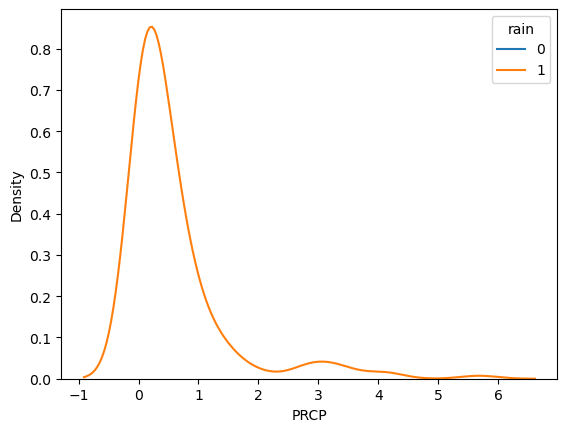

In [24]:
sns.kdeplot(data=data, x='PRCP', hue='rain', common_norm=False)
plt.show()

The most immediate thing I can think of to make the model better for forecasting and simulating the weather is to find out how to treat those NaN values we left alone before, is there a reason they are missing? Could they be masking something we can use?

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [25]:
import pickle
with open('data/taxicab.pkl', 'rb') as f:
    taxicab_data = pickle.load(f)

In [26]:
data = taxicab_data[0].reset_index()
data['index']

0         0
1         0
2         0
3         0
4         0
         ..
26021    29
26022    29
26023    13
26024     3
26025     3
Name: index, Length: 26026, dtype: int64

In [27]:
seq = np.array(data['index'])
states = list(np.unique(seq))
S = len(states)
T = len(seq)
tr_counts = np.zeros((S, S))

for t in range(1, T):
    x_tm1 = states.index(seq[t-1])
    x_t = states.index(seq[t])
    tr_counts[x_t, x_tm1] += 1

print('\nTransition Counts:\n', tr_counts)

sums = tr_counts.sum(axis=1, keepdims=True)
print('\nState Counts:\n', sums)

state_proportions = sums / np.sum(sums)
print('\nState proportions:\n', state_proportions)

tr_pr = np.divide(tr_counts, sums, out=np.zeros_like(tr_counts), where=sums!=0)
tr_pr_1 = tr_pr
print('\nTransition Proportions:\n')
transition_matrix = pd.DataFrame(np.round(tr_pr, 2), index=states, columns=states)
transition_matrix


Transition Counts:
 [[1.516e+03 1.400e+01 7.000e+00 ... 5.900e+01 4.000e+00 3.500e+01]
 [1.800e+01 1.070e+02 4.000e+00 ... 4.000e+00 1.000e+00 2.700e+01]
 [5.000e+00 0.000e+00 8.100e+01 ... 6.000e+01 0.000e+00 3.000e+00]
 ...
 [5.000e+01 8.000e+00 8.100e+01 ... 7.220e+02 5.000e+00 2.800e+01]
 [7.000e+00 0.000e+00 0.000e+00 ... 7.000e+00 8.000e+00 0.000e+00]
 [4.000e+01 2.300e+01 9.000e+00 ... 1.600e+01 1.000e+00 2.730e+02]]

State Counts:
 [[2809.]
 [ 379.]
 [ 457.]
 [2484.]
 [  95.]
 [  74.]
 [ 214.]
 [ 939.]
 [ 627.]
 [ 457.]
 [ 583.]
 [ 600.]
 [ 174.]
 [1280.]
 [  19.]
 [ 557.]
 [  71.]
 [ 409.]
 [4389.]
 [ 153.]
 [ 767.]
 [ 309.]
 [ 243.]
 [   7.]
 [ 798.]
 [  90.]
 [1112.]
 [ 464.]
 [   8.]
 [2891.]
 [1641.]
 [  55.]
 [ 870.]]

State proportions:
 [[0.10793468]
 [0.01456292]
 [0.01756004]
 [0.09544669]
 [0.00365034]
 [0.00284342]
 [0.00822286]
 [0.03608069]
 [0.02409222]
 [0.01756004]
 [0.02240154]
 [0.02305476]
 [0.00668588]
 [0.04918348]
 [0.00073007]
 [0.0214025 ]
 [0.00272815

,0,1,2,3,4,5,6,7,9,10,...,28,29,30,31,32,33,34,35,36,37
0,0.54,0.00,0.00,0.04,0.00,0.00,0.01,0.03,0.02,0.01,...,0.00,0.02,0.00,0.02,0.01,0.0,0.04,0.02,0.00,0.01
1,0.05,0.28,0.01,0.05,0.00,0.01,0.00,0.01,0.15,0.01,...,0.00,0.06,0.00,0.02,0.08,0.0,0.03,0.01,0.00,0.07
2,0.01,0.00,0.18,0.02,0.00,0.00,0.03,0.00,0.00,0.00,...,0.00,0.01,0.00,0.02,0.00,0.0,0.30,0.13,0.00,0.01
3,0.04,0.01,0.01,0.36,0.00,0.00,0.00,0.03,0.01,0.03,...,0.00,0.02,0.00,0.06,0.01,0.0,0.03,0.02,0.00,0.05
4,0.16,0.03,0.00,0.04,0.12,0.01,0.00,0.07,0.11,0.00,...,0.00,0.07,0.00,0.04,0.03,0.0,0.00,0.01,0.00,0.01
5,0.20,0.00,0.01,0.05,0.05,0.11,0.00,0.04,0.07,0.03,...,0.00,0.05,0.03,0.03,0.11,0.0,0.03,0.01,0.00,0.00
6,0.07,0.00,0.02,0.03,0.00,0.00,0.20,0.02,0.01,0.01,...,0.00,0.00,0.00,0.05,0.00,0.0,0.25,0.06,0.00,0.00
7,0.06,0.01,0.00,0.08,0.01,0.00,0.00,0.28,0.02,0.01,...,0.00,0.05,0.01,0.02,0.01,0.0,0.03,0.01,0.00,0.03
9,0.13,0.07,0.00,0.04,0.01,0.01,0.00,0.04,0.30,0.01,...,0.00,0.03,0.01,0.03,0.03,0.0,0.04,0.01,0.00,0.02
10,0.03,0.02,0.01,0.15,0.00,0.00,0.00,0.04,0.01,0.20,...,0.00,0.03,0.00,0.03,0.02,0.0,0.04,0.02,0.00,0.02


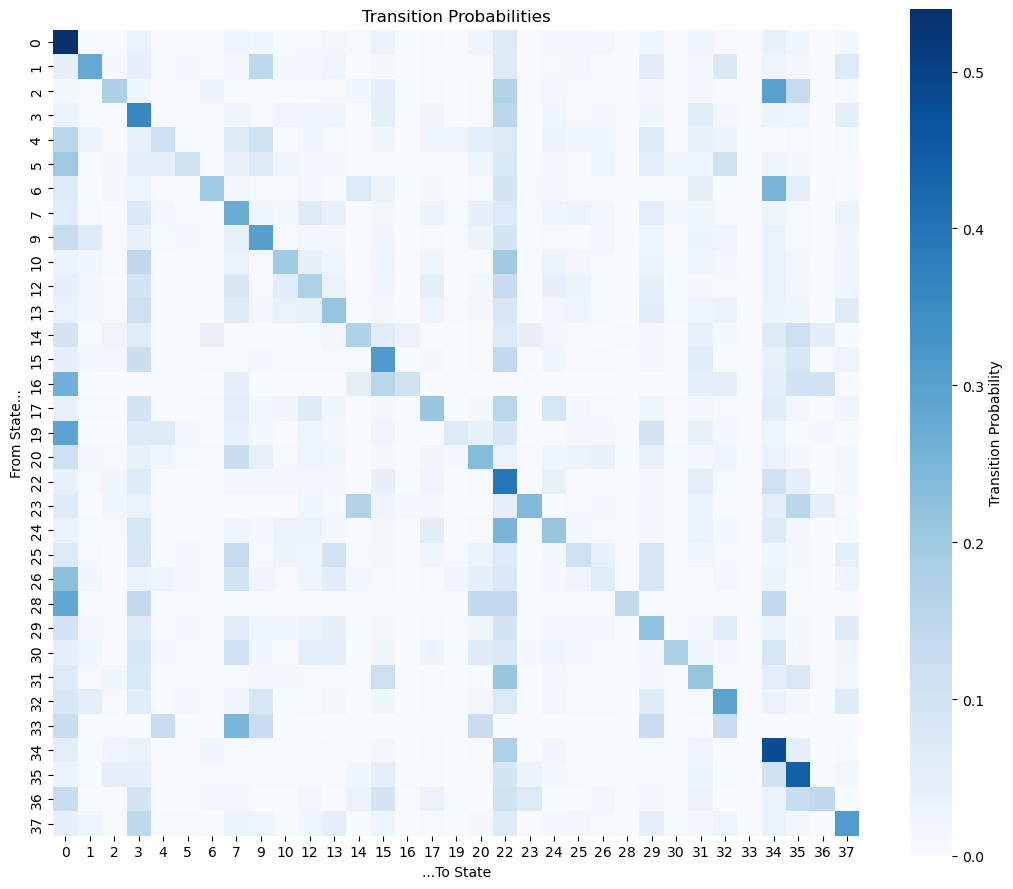

In [28]:
plt.figure(figsize=(13, 11))
sns.heatmap(tr_pr, 
            cmap='Blues',
            square=True,          
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.show()

The most common routes seem to be to be from neighborhood 0 to 0, 22 to 22, with some other routes on the diagonal (route starting and ending same neighborhood) being notable as well. For inter-neighrobrhood routes, 16, 19, 28 to 0 is a somewhat frequent route, as well as 2 and 6 to 34. To see what neighorhoods these are in name, we can loot at the key value pairs here:

In [31]:
value_counts = data.drop_duplicates(subset='index')
value_counts

,index,nbhd
0,0,Outside Manhattan
7,2,Central Park
9,34,Upper East Side
11,35,Upper West Side
14,20,Lower East Side
15,12,Gramercy
16,17,Kips Bay
17,22,Midtown
18,3,Chelsea
23,31,Theater District


Taxicabs are most likely order 1, and not 2 or more because most people take taxis to go home, or go to some place directly. This means there isn't a lot of cases where detours or other stops are going to be made, as this is what both the driver and rider want, to not waste time or money.

NOTE: We have a lot of states so instead of printing forecast we will graph like showed in class.

Hell's kitchen is neighorhood 15, so:

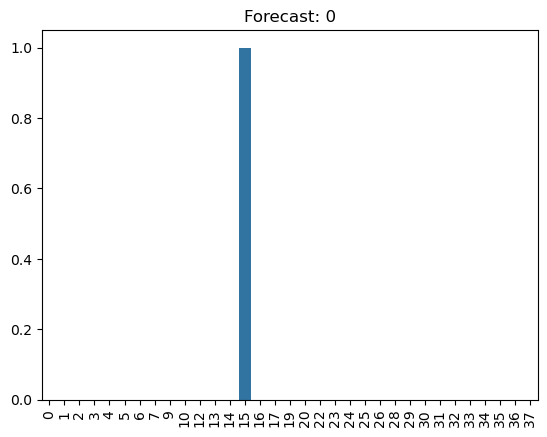

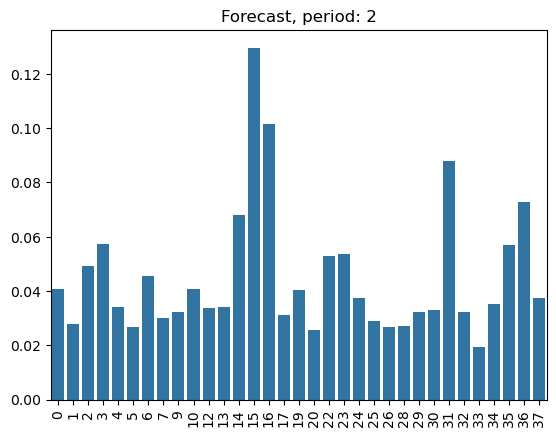

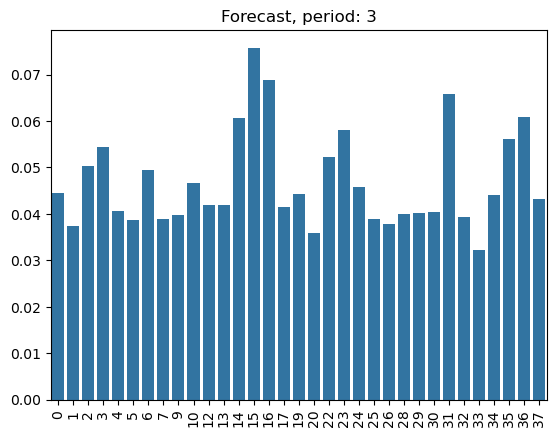

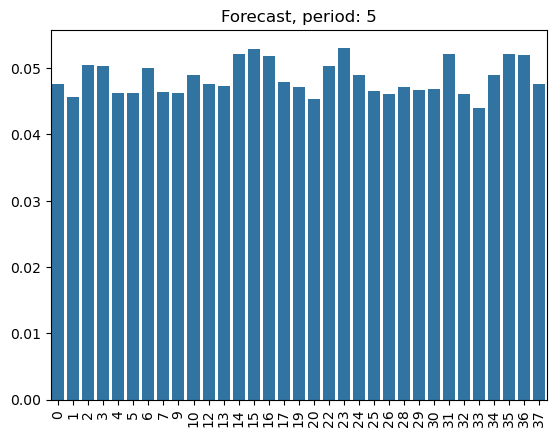

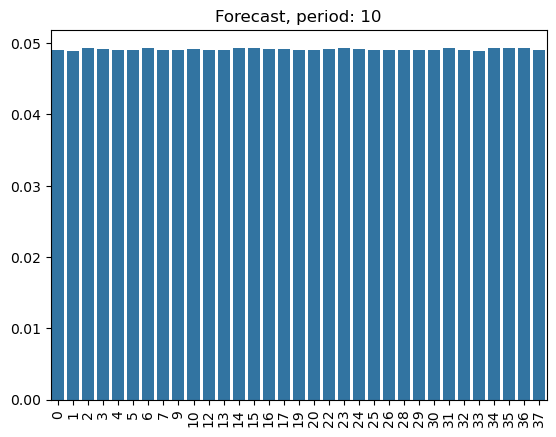

In [33]:
initial_state = 15
state_index = states.index(initial_state) # Get the index of the initial state

##Initial density:
density = np.zeros(len(states))
density[state_index] = 1

sns.barplot(x=states,y=density).set(title=f'Forecast: 0')
plt.xticks(rotation=90)
plt.show()

n_sim = 10

forecast = [initial_state]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
    
    if t in [1, 2, 4, 9]:
        sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
        plt.xticks(rotation=90)
        plt.show()


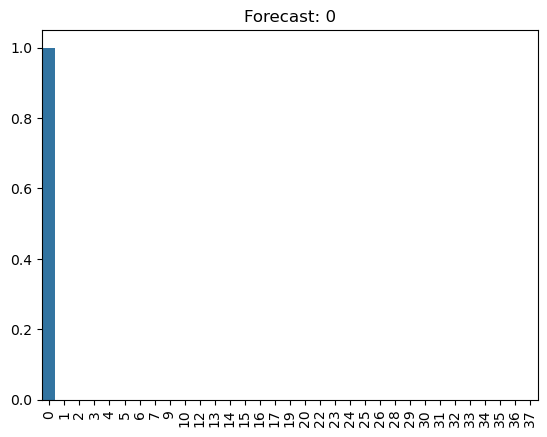

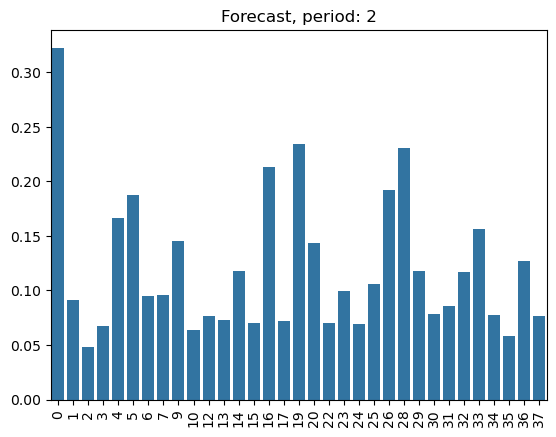

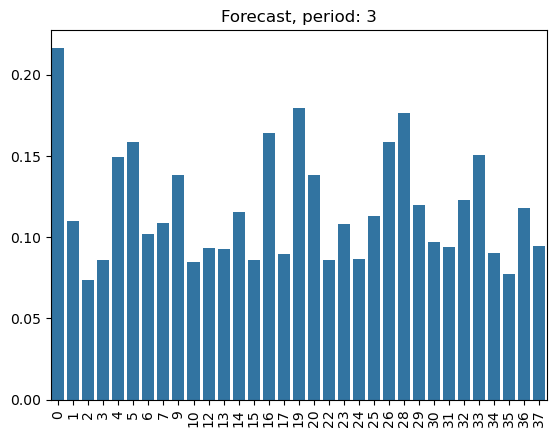

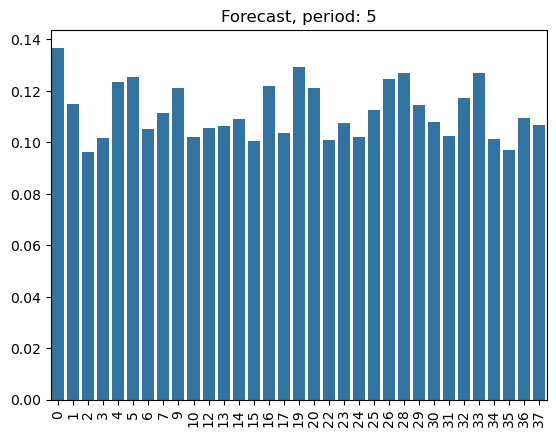

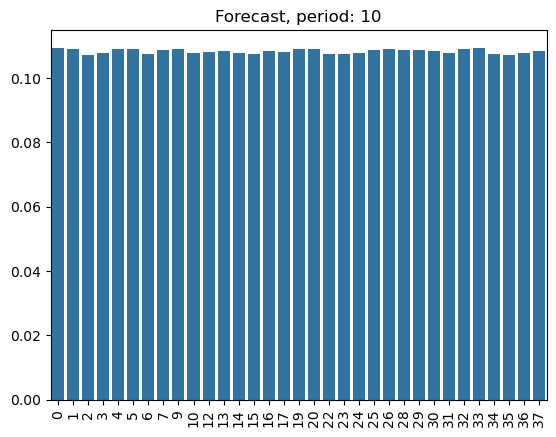

In [34]:
initial_state = 0
state_index = states.index(initial_state) # Get the index of the initial state

##Initial density:
density = np.zeros(len(states))
density[state_index] = 1

sns.barplot(x=states,y=density).set(title=f'Forecast: 0')
plt.xticks(rotation=90)
plt.show()

n_sim = 10

forecast = [initial_state]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
    
    if t in [1, 2, 4, 9]:
        sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
        plt.xticks(rotation=90)
        plt.show()


It would depend on context as some taxicabs just do a few long drives a day. But it appears based on the forecast that cabs that make separate drive frequently (closer to 10+) seem to spend their time equally between all neighorhoods in Manhattan.